<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
INSURANCE CHARGERS PREDICTION</h1>

<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
IMPORT LIBRARIES</h1>

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("insurance.csv")

In [5]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
EXPLORATORY DATA ANALYSIS</h1>

In [6]:
data.shape

(1338, 7)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
UNIVARIANT ANALYSIS</h1>

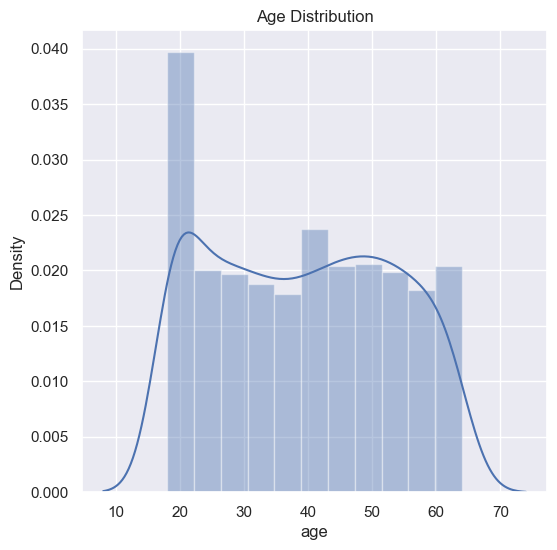

In [11]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(data['age'])
plt.title('Age Distribution')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

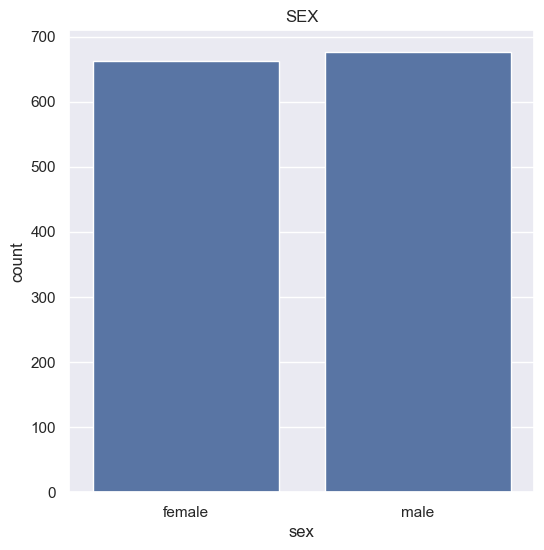

In [12]:
sns.set()
plt.figure(figsize =(6,6))
sns.countplot(x = 'sex', data = data)
plt.title('SEX')
plt.show

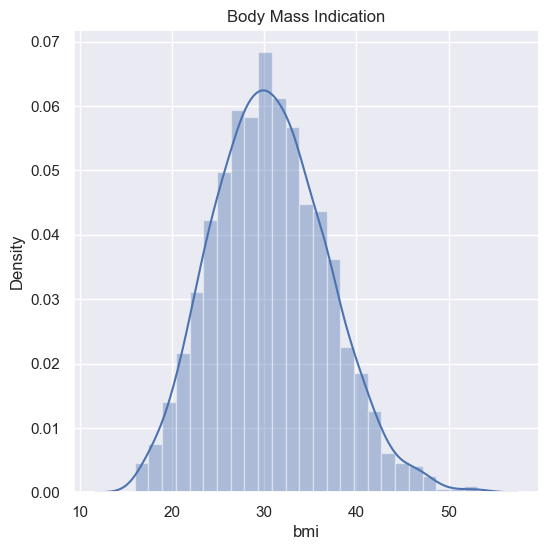

In [13]:
sns.set()
plt.figure(figsize = (6,6))
sns.distplot(data['bmi'])
plt.title('Body Mass Indication')
plt.show()

<Axes: xlabel='children', ylabel='count'>

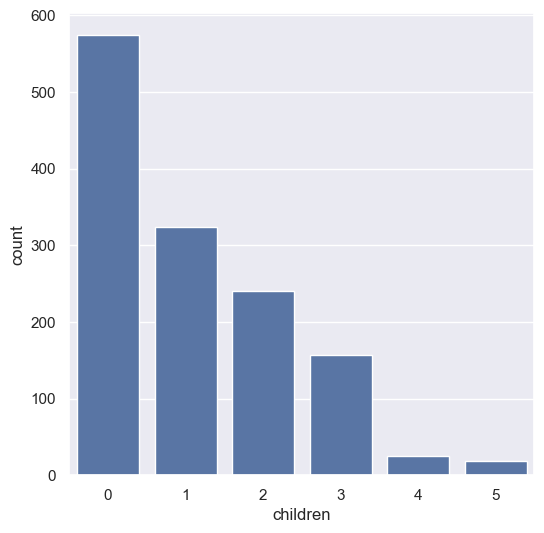

In [14]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x = 'children', data = data)

In [15]:
data['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

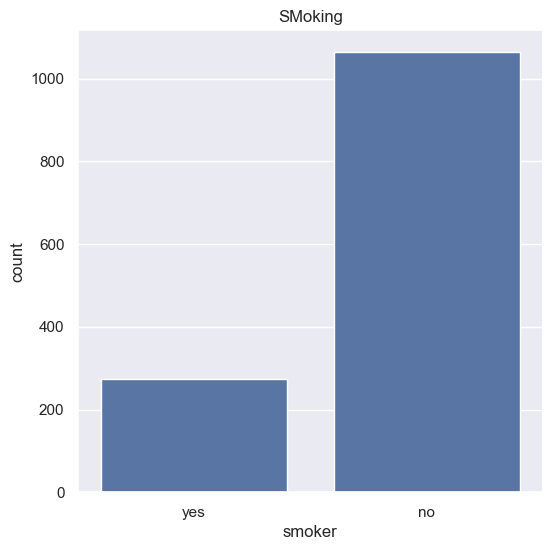

In [16]:
sns.set()
plt.figure (figsize =(6,6))
sns.countplot(x = 'smoker', data = data)
plt.title('SMoking')
plt.show()

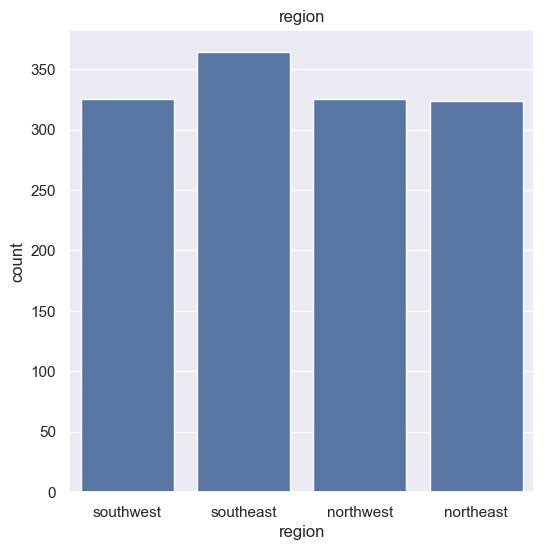

In [17]:
sns.set()
plt.figure (figsize =(6,6))
sns.countplot(x = 'region', data = data)
plt.title('region')
plt.show()

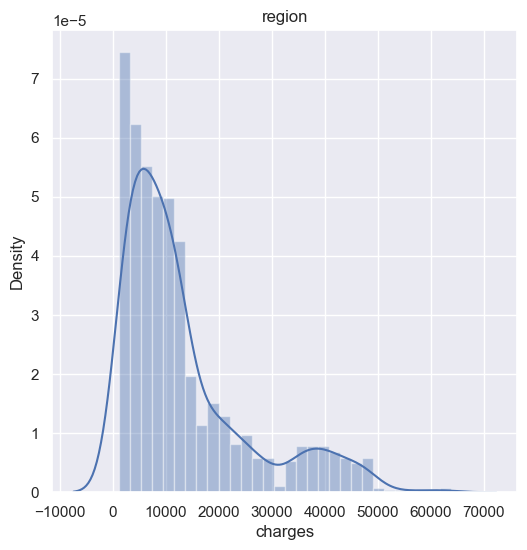

In [18]:
sns.set()
plt.figure (figsize =(6,6))
sns.distplot(data['charges'])
plt.title('region')
plt.show()


<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
LABEL ENCODING USING REPLACE METHOD</h1>

In [19]:
data.replace({'sex' : {'male': 0,'female': 1}}, inplace =True)

In [20]:
data.replace({'smoker' :{'yes':0, 'no':1}}, inplace =True)

In [21]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [22]:
data.replace({'region':{'southwest' : 1, 'southeast':0, 'northeast':2, 'northwest':3}}, inplace =True)

<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
DATA PARTITIONING</h1>

In [23]:
x = data.drop(['charges'], axis =1)

In [24]:
y = data['charges']

In [25]:
from sklearn.model_selection import train_test_split

<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
STRATIFICATION</h1>

In [30]:
stratify = pd.qcut(data['charges'], q=4, labels=False)  # Quartiles

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x, y, random_state = 2,stratify = stratify,test_size =0.2)

In [32]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(1070, 6) (268, 6) (1070,) (268,)


<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
MODELLING </h1>

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()

In [35]:
model.fit(x_train, y_train)

LinearRegression()

In [36]:
predict = model.predict(x_train)

In [37]:
predict

array([10482.03730708, 24552.77896877, 31319.41396046, ...,
       29210.49933585, 15100.15544918, 13913.29998574])

In [38]:
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [39]:
metrics.r2_score(y_train, predict)

0.7449551470122517

In [40]:
predict2 = model.predict(x_test)

In [41]:
metrics.r2_score(y_test, predict2)

0.7677385931369326

In [42]:
input = (31,1,25,74,0,1)

inputtonumpy = np.asarray(input) 

In [43]:
inputtoreshape = inputtonumpy.reshape(1,-1)

In [44]:
new = model.predict(inputtoreshape)

In [45]:
new

array([60380.44086451])

<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
Ordinary Least Square</h1>

In [47]:
import statsmodels.api as sm
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     667.1
Date:                Tue, 05 Aug 2025   Prob (F-statistic):               0.00
Time:                        19:40:05   Log-Likelihood:                -13549.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.083e+04   1087.719      9.957      0.0

<h1 style="font-family:Arial; font-size:32px; color:#2C3E50; text-align:center; background-color:#ECF0F1; padding:10px; border-radius:10px;">
Statistics model</h1>

In [51]:
print(model.resid)

0       -8657.650436
1       -1712.890163
2       -2235.859337
3       17995.527383
4       -1946.246464
            ...     
1333    -1947.420136
1334     -865.242755
1335    -2507.246519
1336      526.244808
1337    -8183.861808
Length: 1338, dtype: float64


In [53]:
print(model.params)

const       10830.405719
age           256.967966
sex           128.956085
bmi           337.024519
children      468.354047
smoker     -23867.058687
region        297.837207
dtype: float64


In [54]:
print(model.pvalues)

const       1.415191e-22
age         6.224579e-89
sex         6.986355e-01
bmi         5.912914e-31
children    6.934002e-04
smoker      0.000000e+00
region      5.070032e-02
dtype: float64


In [55]:
print(model.conf_int())

                     0             1
const      8696.574581  12964.236857
age         233.627584    280.308348
sex        -524.320871    782.233042
bmi         281.317200    392.731838
children    198.133746    738.574348
smoker   -24676.654388 -23057.462987
region       -0.909202    596.583616
